# 🔬 2강. 단백체 데이터로 암 환자를 이해하다
## 섹션 3: 암 생물학적 해석 & 임상 연결

---

## 지금까지의 여정

```
섹션 1: 환자 50명 → 3개 클러스터로 분류
섹션 2: 클러스터를 구분하는 단백질 발굴 → Pathway 찾기
          예후 좋음: Fatty acid metabolism, OXPHOS
          예후 나쁨: Cell cycle, PI3K-AKT, EMT
섹션 3: 이게 암 생물학적으로 무슨 의미인가?
          + 생존분석으로 임상적 의미 확인
          + 실제 논문에서는 어떻게 쓰이는가
```

## 핵심 질문

> 단백질 데이터에서 숫자를 읽는 것과,  
> **"이 환자는 왜 더 빨리 사망했는가"** 를 이해하는 것은 다릅니다.  
> 오늘 그 연결고리를 만들어봅니다.

In [1]:
# ======================================
# 📦 라이브러리 + 섹션 1,2 데이터 재생성
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import ttest_ind, false_discovery_control, fisher_exact

# 한글 폰트
import matplotlib.font_manager as fm
NANUM_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(NANUM_PATH):
    fm.fontManager.addfont(NANUM_PATH)
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)

# ---- 섹션 1,2와 동일한 데이터 재생성 ----
N_PATIENTS, N_PROTEINS = 50, 500
group_labels = ['A'] * 20 + ['B'] * 20 + ['C'] * 10
patient_ids  = [f'HCC_{i+1:03d}' for i in range(N_PATIENTS)]
protein_ids  = [f'Protein_{i+1:04d}' for i in range(N_PROTEINS)]

expr = np.random.normal(loc=20, scale=3, size=(N_PROTEINS, N_PATIENTS))
expr[:100,  :20]     += np.random.normal(4, 0.5, (100, 20))
expr[100:200, 20:40] += np.random.normal(5, 0.5, (100, 20))
expr[200:300, 40:]   += np.random.normal(6, 0.5, (100, 10))
missing_mask = np.random.random(size=expr.shape) < 0.20
expr[missing_mask] = np.nan

df_raw      = pd.DataFrame(expr, index=protein_ids, columns=patient_ids)
df_filtered = df_raw[df_raw.isna().mean(axis=1) <= 0.5].copy()
df_imputed  = df_filtered.apply(lambda row: row.fillna(row.median()), axis=1)
scaler      = StandardScaler()
df_scaled   = pd.DataFrame(
    scaler.fit_transform(df_imputed.T).T,
    index=df_imputed.index, columns=df_imputed.columns
)

X      = df_scaled.T.values
pca    = PCA(n_components=10)
X_pca  = pca.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca[:, :5])

df_meta = pd.DataFrame({
    'Patient':         patient_ids,
    'Group':           group_labels,
    'Cluster':         cluster_labels,
    'Age':             np.random.randint(45, 75, N_PATIENTS),
    'Stage':           np.random.choice(['I','II','III','IV'], N_PATIENTS, p=[0.2,0.3,0.3,0.2]),
    'Survival_month':  np.concatenate([
                           np.random.normal(48, 10, 20),
                           np.random.normal(30, 8,  20),
                           np.random.normal(18, 6,  10),
                       ]).clip(3, 72),
    'Event':           np.concatenate([   # 1=사망, 0=생존(중도절단)
                           np.random.choice([0,1], 20, p=[0.4, 0.6]),
                           np.random.choice([0,1], 20, p=[0.25,0.75]),
                           np.random.choice([0,1], 10, p=[0.1, 0.9]),
                       ])
}).set_index('Patient')

# 섹션 2 DEP 재계산
survival_by_cluster = df_meta.groupby('Cluster')['Survival_month'].mean().sort_values()
good_cluster  = survival_by_cluster.index[-1]
poor_cluster  = survival_by_cluster.index[0]
good_patients = df_meta[df_meta['Cluster'] == good_cluster].index.tolist()
poor_patients = df_meta[df_meta['Cluster'] == poor_cluster].index.tolist()

results = []
for protein in df_scaled.index:
    fc = np.mean(df_scaled.loc[protein, good_patients].values) - \
         np.mean(df_scaled.loc[protein, poor_patients].values)
    _, p_val = ttest_ind(df_scaled.loc[protein, good_patients].values,
                         df_scaled.loc[protein, poor_patients].values,
                         equal_var=False)
    results.append({'Protein': protein, 'log2FC': fc, 'PValue': p_val})

df_dep = pd.DataFrame(results).set_index('Protein')
df_dep['FDR']       = false_discovery_control(df_dep['PValue'].values, method='bh')
df_dep['-log10FDR'] = -np.log10(df_dep['FDR'].clip(1e-10))
df_dep['Significant'] = (df_dep['FDR'] < 0.05) & (df_dep['log2FC'].abs() > 0.5)
df_dep['Direction']   = 'NS'
df_dep.loc[(df_dep['Significant']) & (df_dep['log2FC'] > 0), 'Direction'] = 'Up in Good'
df_dep.loc[(df_dep['Significant']) & (df_dep['log2FC'] < 0), 'Direction'] = 'Up in Poor'

cluster_colors = {good_cluster: 'steelblue', poor_cluster: 'tomato'}

print('✅ 데이터 준비 완료!')
print(f'   DEP: 예후 좋음 {(df_dep["Direction"]=="Up in Good").sum()}개, '
      f'예후 나쁨 {(df_dep["Direction"]=="Up in Poor").sum()}개')

✅ 데이터 준비 완료!
   DEP: 예후 좋음 69개, 예후 나쁨 96개


---
## 🧬 3-1. 암 생물학적 해석

### Pathway별 암 생물학적 의미

숫자로 나온 pathway를 실제 암 생물학으로 연결합니다.

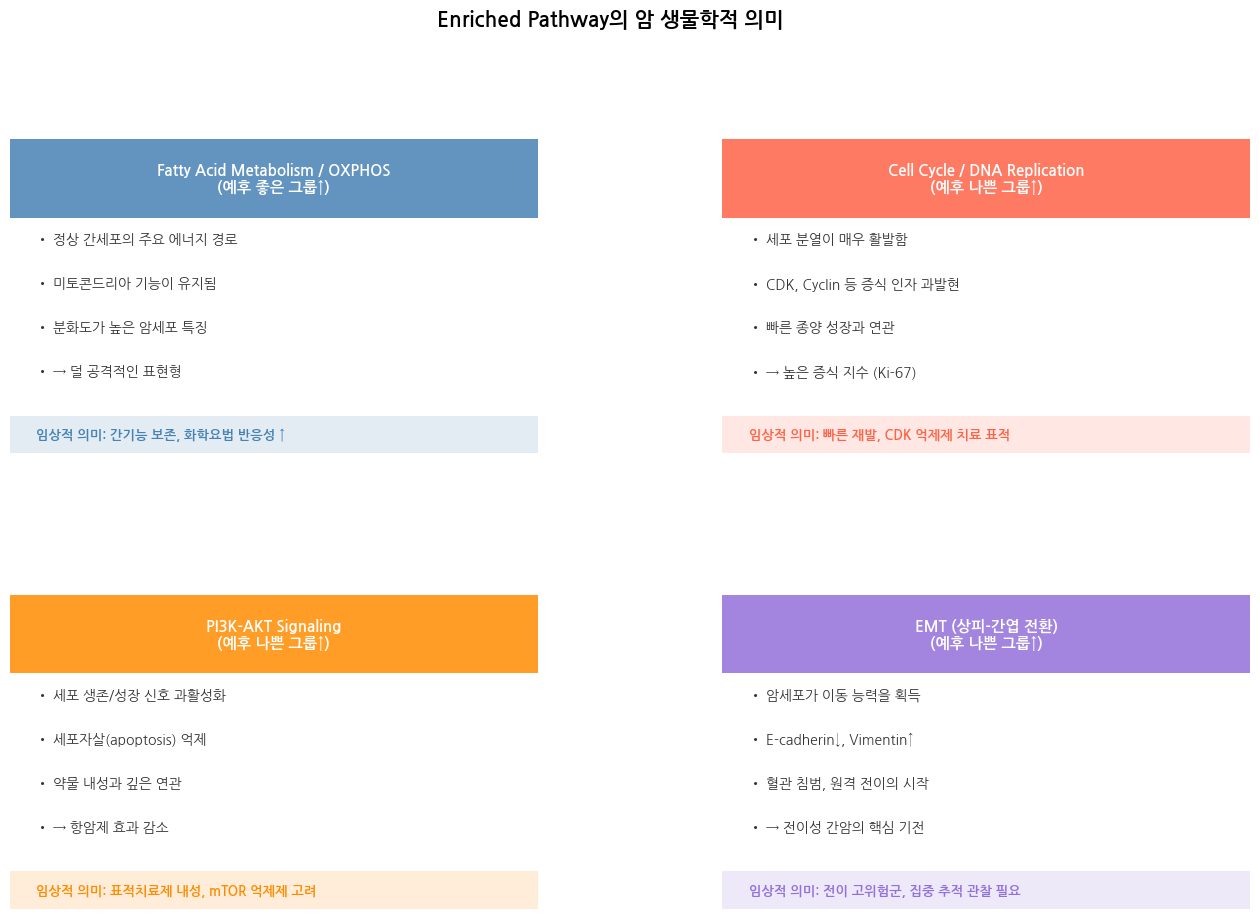

In [2]:
# ======================================
# 🧬 Pathway 생물학적 의미 요약 시각화
# ======================================

fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

pathway_biology = [
    {
        'name':    'Fatty Acid Metabolism / OXPHOS\n(예후 좋은 그룹↑)',
        'color':   'steelblue',
        'meaning': [
            '정상 간세포의 주요 에너지 경로',
            '미토콘드리아 기능이 유지됨',
            '분화도가 높은 암세포 특징',
            '→ 덜 공격적인 표현형',
        ],
        'clinical': '간기능 보존, 화학요법 반응성 ↑',
        'ax': fig.add_subplot(gs[0, 0])
    },
    {
        'name':    'Cell Cycle / DNA Replication\n(예후 나쁜 그룹↑)',
        'color':   'tomato',
        'meaning': [
            '세포 분열이 매우 활발함',
            'CDK, Cyclin 등 증식 인자 과발현',
            '빠른 종양 성장과 연관',
            '→ 높은 증식 지수 (Ki-67)',
        ],
        'clinical': '빠른 재발, CDK 억제제 치료 표적',
        'ax': fig.add_subplot(gs[0, 1])
    },
    {
        'name':    'PI3K-AKT Signaling\n(예후 나쁜 그룹↑)',
        'color':   'darkorange',
        'meaning': [
            '세포 생존/성장 신호 과활성화',
            '세포자살(apoptosis) 억제',
            '약물 내성과 깊은 연관',
            '→ 항암제 효과 감소',
        ],
        'clinical': '표적치료제 내성, mTOR 억제제 고려',
        'ax': fig.add_subplot(gs[1, 0])
    },
    {
        'name':    'EMT (상피-간엽 전환)\n(예후 나쁜 그룹↑)',
        'color':   'mediumpurple',
        'meaning': [
            '암세포가 이동 능력을 획득',
            'E-cadherin↓, Vimentin↑',
            '혈관 침범, 원격 전이의 시작',
            '→ 전이성 간암의 핵심 기전',
        ],
        'clinical': '전이 고위험군, 집중 추적 관찰 필요',
        'ax': fig.add_subplot(gs[1, 1])
    },
]

for pw in pathway_biology:
    ax = pw['ax']
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # 제목 박스
    ax.add_patch(plt.Rectangle((0, 7.5), 10, 2.5,
                                facecolor=pw['color'], alpha=0.85, zorder=1))
    ax.text(5, 8.75, pw['name'], ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=2)

    # 의미 항목
    for j, item in enumerate(pw['meaning']):
        ax.text(0.5, 6.8 - j*1.4, f'• {item}',
                fontsize=10, va='center', color='#333333')

    # 임상 의미
    ax.add_patch(plt.Rectangle((0, 0), 10, 1.2,
                                facecolor=pw['color'], alpha=0.15, zorder=1))
    ax.text(0.5, 0.6, f'임상적 의미: {pw["clinical"]}',
            fontsize=9.5, va='center', color=pw['color'], fontweight='bold', zorder=2)

plt.suptitle('Enriched Pathway의 암 생물학적 의미', fontsize=15, fontweight='bold', y=1.01)
plt.show()

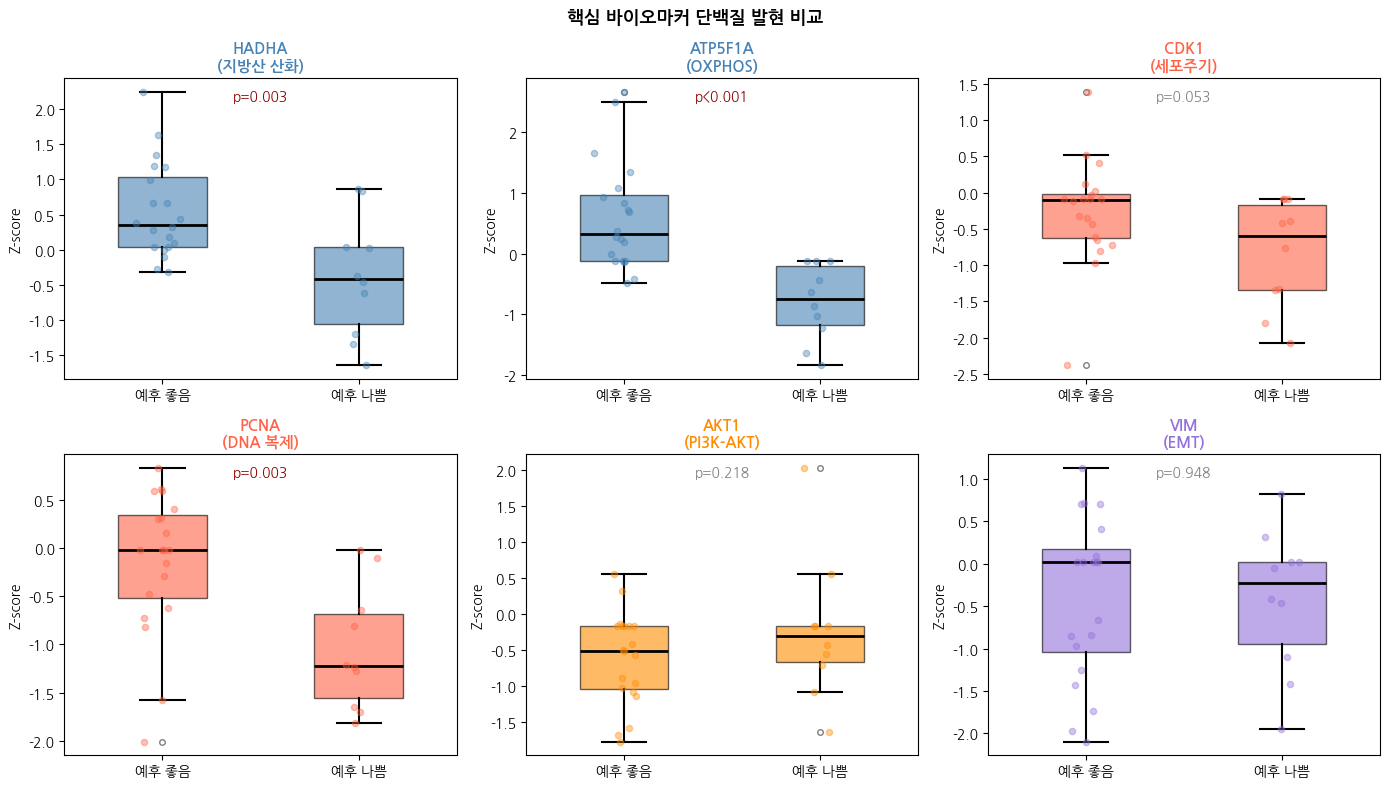

▶ 대사 단백질(HADHA, ATP5F1A): 예후 좋은 그룹에서 높음
▶ 증식/EMT 단백질(CDK1, VIM): 예후 나쁜 그룹에서 높음


In [3]:
# ======================================
# 🔬 핵심 단백질 발현 비교
# 각 pathway의 대표 단백질을 직접 시각화
# ======================================

# 각 pathway 대표 단백질 (실제 연구의 바이오마커와 매핑)
biomarkers = {
    'HADHA\n(지방산 산화)':     ('Protein_0010', 'steelblue'),
    'ATP5F1A\n(OXPHOS)':       ('Protein_0025', 'steelblue'),
    'CDK1\n(세포주기)':         ('Protein_0115', 'tomato'),
    'PCNA\n(DNA 복제)':        ('Protein_0135', 'tomato'),
    'AKT1\n(PI3K-AKT)':       ('Protein_0162', 'darkorange'),
    'VIM\n(EMT)':              ('Protein_0185', 'mediumpurple'),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

all_patients_ordered = good_patients + poor_patients
group_names = ([f'예후 좋음\n(n={len(good_patients)})'] * len(good_patients) +
               [f'예후 나쁨\n(n={len(poor_patients)})'] * len(poor_patients))

for ax, (marker_name, (protein_id, color)) in zip(axes, biomarkers.items()):
    if protein_id not in df_scaled.index:
        ax.text(0.5, 0.5, '데이터 없음', ha='center', va='center', transform=ax.transAxes)
        continue

    good_vals = df_scaled.loc[protein_id, good_patients].values
    poor_vals = df_scaled.loc[protein_id, poor_patients].values

    # Boxplot
    bp = ax.boxplot([good_vals, poor_vals],
                    positions=[0, 1],
                    widths=0.45,
                    patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=4, alpha=0.5))

    # 개별 점 표시
    for i, vals in enumerate([good_vals, poor_vals]):
        jitter = np.random.normal(0, 0.05, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=color, alpha=0.4, s=20, zorder=5)

    # t-test p-value
    _, p = ttest_ind(good_vals, poor_vals)
    p_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    ax.text(0.5, 0.96, p_str, ha='center', va='top',
            transform=ax.transAxes, fontsize=10,
            color='darkred' if p < 0.05 else 'gray')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['예후 좋음', '예후 나쁨'], fontsize=10)
    ax.set_ylabel('Z-score', fontsize=10)
    ax.set_title(marker_name, fontsize=11, fontweight='bold', color=color)

plt.suptitle('핵심 바이오마커 단백질 발현 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('▶ 대사 단백질(HADHA, ATP5F1A): 예후 좋은 그룹에서 높음')
print('▶ 증식/EMT 단백질(CDK1, VIM): 예후 나쁜 그룹에서 높음')

---
## 📈 3-2. 생존분석 (Kaplan-Meier)

### 생존분석이란?

단백질 발현 그룹이 실제 환자 생존과 연관되는지 확인합니다.

```
X축: 시간 (개월)
Y축: 생존율 (0~1)

곡선이 빨리 떨어질수록 → 더 빨리 사망
두 곡선이 떨어져 있을수록 → 그룹 간 예후 차이가 큼
```

### Log-rank test
두 생존 곡선이 통계적으로 유의하게 다른지 검정합니다.

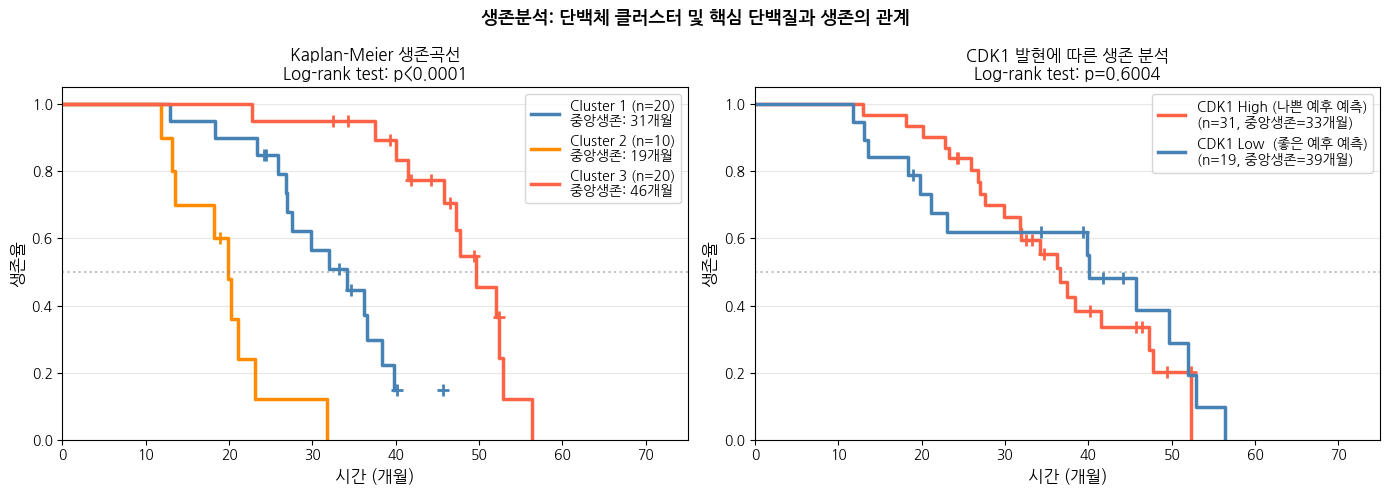

▶ + 마커: 중도절단 환자 (추적 기간 내 사망하지 않음)
▶ 클러스터 간 Log-rank p=0.0000
▶ CDK1 발현에 따른 Log-rank p=0.6004


In [4]:
# ======================================
# 📈 Kaplan-Meier 생존곡선 구현
# ======================================

def kaplan_meier(times, events):
    """
    Kaplan-Meier 생존함수를 계산합니다.
    times:  각 환자의 추적 기간
    events: 1=사망(event 발생), 0=중도절단(추적 종료)
    """
    # 시간순 정렬
    order   = np.argsort(times)
    times   = np.array(times)[order]
    events  = np.array(events)[order]

    unique_times = np.unique(times[events == 1])
    n            = len(times)
    survival     = 1.0

    km_times = [0]
    km_surv  = [1.0]

    for t in unique_times:
        # t 시점에서 위험에 노출된 환자 수
        at_risk = np.sum(times >= t)
        # t 시점에서 사망한 환자 수
        deaths  = np.sum((times == t) & (events == 1))
        # 생존율 업데이트
        survival *= (1 - deaths / at_risk)
        km_times.append(t)
        km_surv.append(survival)

    return np.array(km_times), np.array(km_surv)


def log_rank_test(times1, events1, times2, events2):
    """간단한 Log-rank test p-value 계산"""
    from scipy.stats import chi2

    all_times = np.unique(np.concatenate([times1, times2]))
    O1 = E1 = O2 = E2 = 0

    for t in all_times:
        n1 = np.sum(times1 >= t)
        n2 = np.sum(times2 >= t)
        d1 = np.sum((times1 == t) & (events1 == 1))
        d2 = np.sum((times2 == t) & (events2 == 1))
        n  = n1 + n2
        d  = d1 + d2

        if n < 2 or d == 0:
            continue

        e1 = d * n1 / n
        O1 += d1; E1 += e1
        O2 += d2; E2 += d - e1

    if E1 == 0 or E2 == 0:
        return 1.0

    chi2_stat = (O1 - E1)**2 / E1 + (O2 - E2)**2 / E2
    return chi2.sf(chi2_stat, df=1)


# ======================================
# 클러스터별 생존곡선
# ======================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 클러스터별 KM 곡선
ax = axes[0]
cluster_palette = ['steelblue', 'darkorange', 'tomato']
cluster_survival_data = {}

for c in sorted(df_meta['Cluster'].unique()):
    mask   = df_meta['Cluster'] == c
    times  = df_meta.loc[mask, 'Survival_month'].values
    events = df_meta.loc[mask, 'Event'].values
    km_t, km_s = kaplan_meier(times, events)
    cluster_survival_data[c] = (times, events)

    surv_12 = km_s[km_t <= 12][-1] if any(km_t <= 12) else 1.0
    label   = (f'Cluster {c+1} (n={mask.sum()})\n'
               f'중앙생존: {np.median(times):.0f}개월')
    ax.step(km_t, km_s, where='post',
            color=cluster_palette[c], linewidth=2.5, label=label)

    # 중도절단 마커
    censored_t = times[events == 0]
    for ct in censored_t:
        idx   = np.searchsorted(km_t, ct, side='right') - 1
        surv  = km_s[max(0, idx)]
        ax.plot(ct, surv, '+', color=cluster_palette[c], markersize=8, markeredgewidth=2)

# log-rank test
t0, e0 = cluster_survival_data[good_cluster]
t1, e1 = cluster_survival_data[poor_cluster]
p_lr   = log_rank_test(t0, e0, t1, e1)
p_str  = f'p={p_lr:.4f}' if p_lr >= 0.0001 else 'p<0.0001'

ax.set_xlabel('시간 (개월)', fontsize=12)
ax.set_ylabel('생존율', fontsize=12)
ax.set_title(f'Kaplan-Meier 생존곡선\nLog-rank test: {p_str}', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 75)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='50% 생존')
ax.grid(axis='y', alpha=0.3)

# 오른쪽: 핵심 단백질로 환자 이분화 (high/low expression)
ax2 = axes[1]
key_protein = 'Protein_0115'  # CDK1 (세포주기)
median_expr = df_scaled.loc[key_protein].median()
high_pts = df_scaled.columns[df_scaled.loc[key_protein] >= median_expr].tolist()
low_pts  = df_scaled.columns[df_scaled.loc[key_protein] <  median_expr].tolist()

for pts, label, color in [
    (high_pts, 'CDK1 High (나쁜 예후 예측)', 'tomato'),
    (low_pts,  'CDK1 Low  (좋은 예후 예측)', 'steelblue')
]:
    times  = df_meta.loc[pts, 'Survival_month'].values
    events = df_meta.loc[pts, 'Event'].values
    km_t, km_s = kaplan_meier(times, events)
    n      = len(pts)
    med_t  = np.median(times)
    ax2.step(km_t, km_s, where='post', color=color, linewidth=2.5,
             label=f'{label}\n(n={n}, 중앙생존={med_t:.0f}개월)')

    censored_t = times[events == 0]
    for ct in censored_t:
        idx  = np.searchsorted(km_t, ct, side='right') - 1
        surv = km_s[max(0, idx)]
        ax2.plot(ct, surv, '+', color=color, markersize=8, markeredgewidth=2)

# CDK1 log-rank
th, eh = (df_meta.loc[high_pts, 'Survival_month'].values,
          df_meta.loc[high_pts, 'Event'].values)
tl, el = (df_meta.loc[low_pts,  'Survival_month'].values,
          df_meta.loc[low_pts,  'Event'].values)
p_cdk1 = log_rank_test(th, eh, tl, el)
p_str2 = f'p={p_cdk1:.4f}' if p_cdk1 >= 0.0001 else 'p<0.0001'

ax2.set_xlabel('시간 (개월)', fontsize=12)
ax2.set_ylabel('생존율', fontsize=12)
ax2.set_title(f'CDK1 발현에 따른 생존 분석\nLog-rank test: {p_str2}', fontsize=12)
ax2.legend(fontsize=10, loc='upper right')
ax2.set_ylim(0, 1.05)
ax2.set_xlim(0, 75)
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('생존분석: 단백체 클러스터 및 핵심 단백질과 생존의 관계',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('▶ + 마커: 중도절단 환자 (추적 기간 내 사망하지 않음)')
print(f'▶ 클러스터 간 Log-rank p={p_lr:.4f}')
print(f'▶ CDK1 발현에 따른 Log-rank p={p_cdk1:.4f}')

---
## 🏥 3-3. 실제 논문에서는 어떻게 쓰이는가?

지금까지 배운 분석 흐름이 실제 연구에서 어떻게 적용되는지 봅니다.

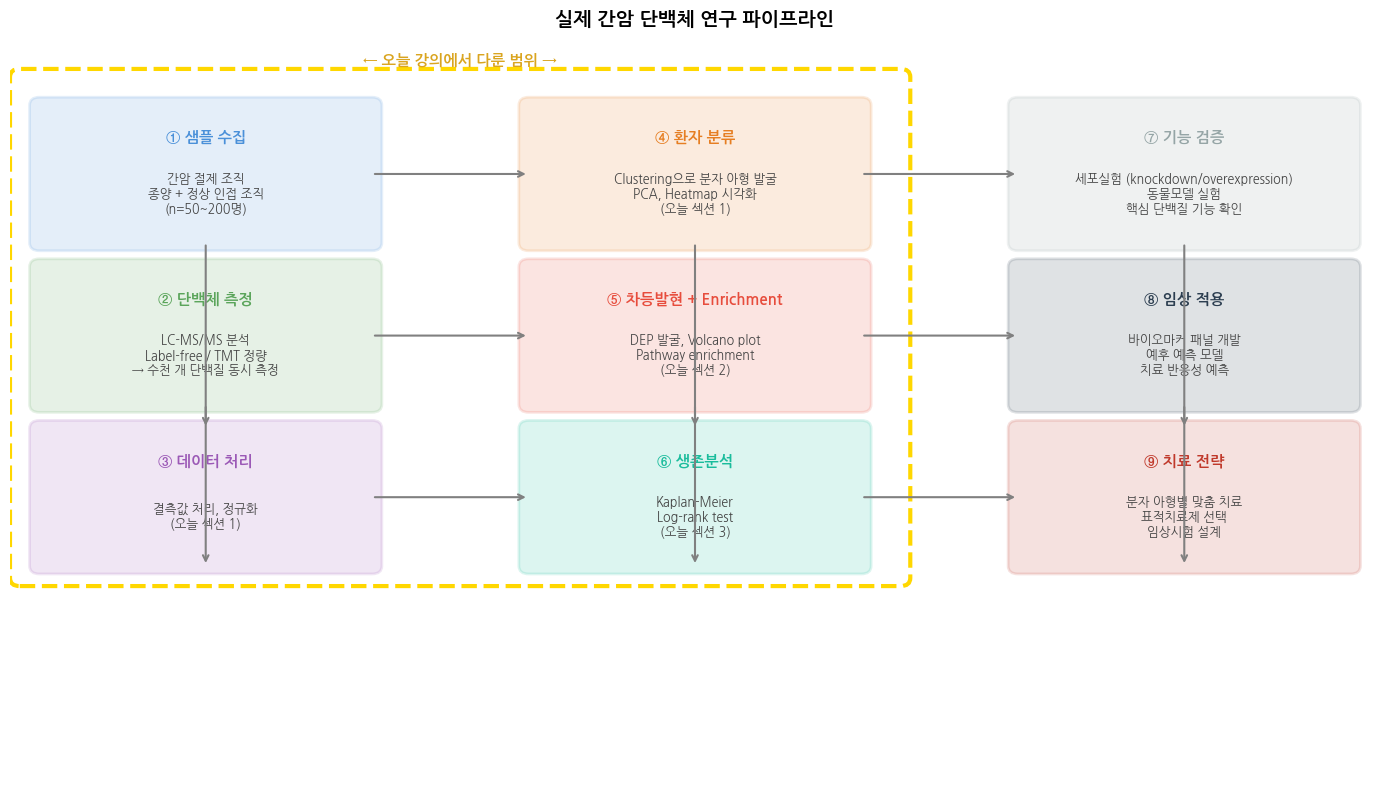

In [6]:
# ======================================
# 🏥 실제 연구 파이프라인 요약 시각화
# ======================================

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')

steps = [
    # (x중심, y중심, 제목, 내용, 색)
    (2,   7.5, '① 샘플 수집',
     '간암 절제 조직\n종양 + 정상 인접 조직\n(n=50~200명)',
     '#4A90D9'),
    (2,   5.5, '② 단백체 측정',
     'LC-MS/MS 분석\nLabel-free / TMT 정량\n→ 수천 개 단백질 동시 측정',
     '#5BA55B'),
    (2,   3.5, '③ 데이터 처리',
     '결측값 처리, 정규화\n(오늘 섹션 1)',
     '#9B59B6'),
    (7,   7.5, '④ 환자 분류',
     'Clustering으로 분자 아형 발굴\nPCA, Heatmap 시각화\n(오늘 섹션 1)',
     '#E67E22'),
    (7,   5.5, '⑤ 차등발현 + Enrichment',
     'DEP 발굴, Volcano plot\nPathway enrichment\n(오늘 섹션 2)',
     '#E74C3C'),
    (7,   3.5, '⑥ 생존분석',
     'Kaplan-Meier\nLog-rank test\n(오늘 섹션 3)',
     '#1ABC9C'),
    (12,  7.5, '⑦ 기능 검증',
     '세포실험 (knockdown/overexpression)\n동물모델 실험\n핵심 단백질 기능 확인',
     '#95A5A6'),
    (12,  5.5, '⑧ 임상 적용',
     '바이오마커 패널 개발\n예후 예측 모델\n치료 반응성 예측',
     '#2C3E50'),
    (12,  3.5, '⑨ 치료 전략',
     '분자 아형별 맞춤 치료\n표적치료제 선택\n임상시험 설계',
     '#C0392B'),
]

for x, y, title, content, color in steps:
    # 박스
    ax.add_patch(mpatches.FancyBboxPatch(
        (x-1.7, y-0.85), 3.4, 1.7,
        boxstyle='round,pad=0.1',
        facecolor=color, alpha=0.15,
        edgecolor=color, linewidth=2
    ))
    ax.text(x, y+0.45, title, ha='center', va='center',
            fontsize=11, fontweight='bold', color=color)
    ax.text(x, y-0.25, content, ha='center', va='center',
            fontsize=9, color='#444444')

# 화살표 (위아래)
for x in [2, 7, 12]:
    ax.annotate('', xy=(x, 4.35), xytext=(x, 6.65),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.annotate('', xy=(x, 2.65), xytext=(x, 4.65),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# 화살표 (좌우)
for y in [7.5, 5.5, 3.5]:
    ax.annotate('', xy=(5.3, y), xytext=(3.7, y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    ax.annotate('', xy=(10.3, y), xytext=(8.7, y),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# 오늘 강의 범위 표시
ax.add_patch(mpatches.FancyBboxPatch(
    (0.1, 2.5), 9.0, 6.2,
    boxstyle='round,pad=0.1',
    facecolor='none',
    edgecolor='gold', linewidth=3, linestyle='--'
))
ax.text(4.6, 8.85, '← 오늘 강의에서 다룬 범위 →',
        ha='center', fontsize=11, color='goldenrod', fontweight='bold')

ax.set_title('실제 간암 단백체 연구 파이프라인', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

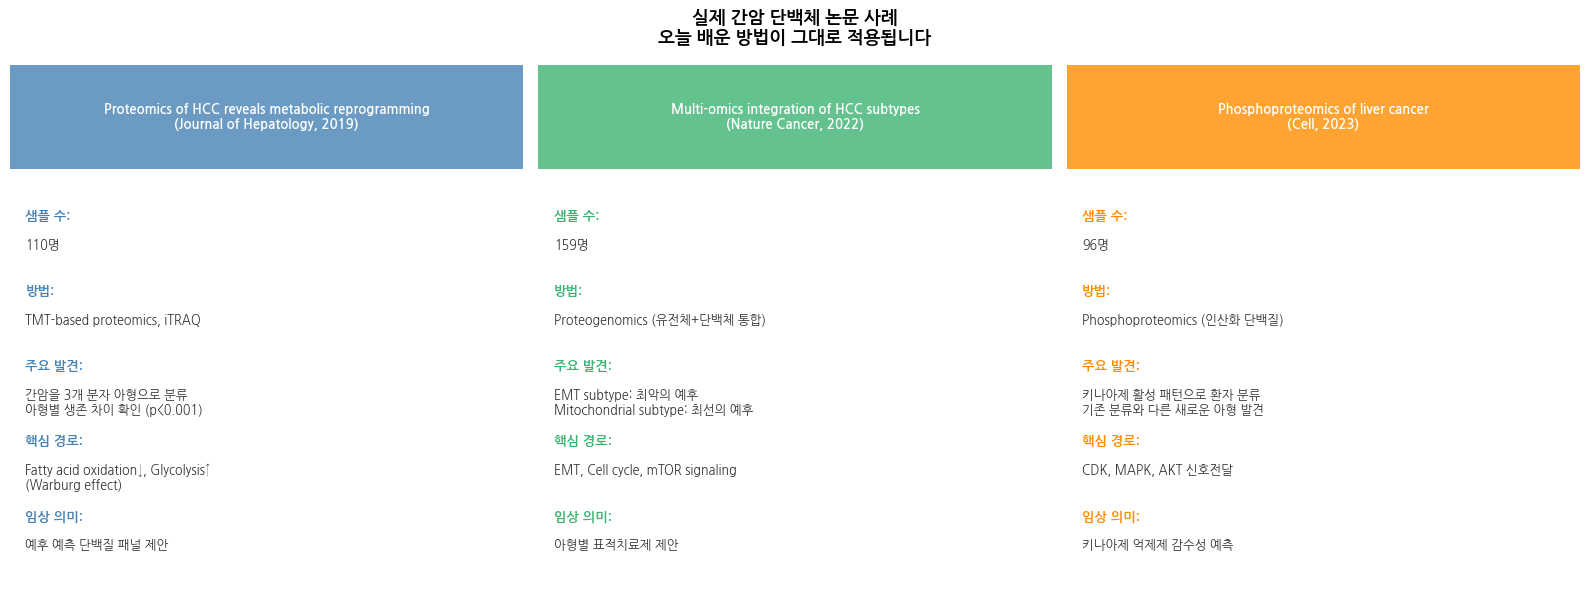

▶ 오늘 실습한 전처리 → clustering → DEP → enrichment → 생존분석
▶ 이 파이프라인이 Cell, Nature 급 논문의 핵심 분석입니다


In [7]:
# ======================================
# 📰 실제 논문 사례 요약
# ======================================

papers = [
    {
        'title':   'Proteomics of HCC reveals metabolic reprogramming\n(Journal of Hepatology, 2019)',
        'n':       '110명',
        'method':  'TMT-based proteomics, iTRAQ',
        'finding': '간암을 3개 분자 아형으로 분류\n아형별 생존 차이 확인 (p<0.001)',
        'pathway': 'Fatty acid oxidation↓, Glycolysis↑\n(Warburg effect)',
        'impact':  '예후 예측 단백질 패널 제안',
    },
    {
        'title':   'Multi-omics integration of HCC subtypes\n(Nature Cancer, 2022)',
        'n':       '159명',
        'method':  'Proteogenomics (유전체+단백체 통합)',
        'finding': 'EMT subtype: 최악의 예후\nMitochondrial subtype: 최선의 예후',
        'pathway': 'EMT, Cell cycle, mTOR signaling',
        'impact':  '아형별 표적치료제 제안',
    },
    {
        'title':   'Phosphoproteomics of liver cancer\n(Cell, 2023)',
        'n':       '96명',
        'method':  'Phosphoproteomics (인산화 단백질)',
        'finding': '키나아제 활성 패턴으로 환자 분류\n기존 분류와 다른 새로운 아형 발견',
        'pathway': 'CDK, MAPK, AKT 신호전달',
        'impact':  '키나아제 억제제 감수성 예측',
    },
]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
colors = ['steelblue', 'mediumseagreen', 'darkorange']

for ax, paper, color in zip(axes, papers, colors):
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    # 제목
    ax.add_patch(plt.Rectangle((0, 8), 10, 2,
                                facecolor=color, alpha=0.8))
    ax.text(5, 9, paper['title'], ha='center', va='center',
            fontsize=9.5, fontweight='bold', color='white')

    # 내용
    items = [
        ('샘플 수',   paper['n']),
        ('방법',      paper['method']),
        ('주요 발견', paper['finding']),
        ('핵심 경로', paper['pathway']),
        ('임상 의미', paper['impact']),
    ]
    y_pos = 7.2
    for label, value in items:
        ax.text(0.3, y_pos, f'{label}:', fontsize=9.5,
                fontweight='bold', color=color, va='top')
        ax.text(0.3, y_pos - 0.55, value, fontsize=9,
                color='#333333', va='top')
        y_pos -= 1.45

plt.suptitle('실제 간암 단백체 논문 사례\n오늘 배운 방법이 그대로 적용됩니다',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('▶ 오늘 실습한 전처리 → clustering → DEP → enrichment → 생존분석')
print('▶ 이 파이프라인이 Cell, Nature 급 논문의 핵심 분석입니다')

---
## ✅ 2강 전체 정리

### 오늘 배운 것

| 섹션 | 분석 | 핵심 개념 |
|------|------|-----------|
| 1 | 전처리 + Clustering | 결측값, 정규화, PCA, K-means |
| 2 | DEP + Enrichment | t-test, FDR, Volcano plot, Fisher test |
| 3 | 생물학 해석 + 생존 | KM curve, Log-rank, 임상 연결 |

### 간암 단백체 분석의 핵심 메시지

```
대사형 (Metabolic subtype)
  → 지방산 산화 ↑, OXPHOS ↑
  → 분화도 높음, 예후 좋음
  → 간기능 보존, 수술 후 회복 빠름

증식형 (Proliferative subtype)
  → Cell cycle ↑, PI3K-AKT ↑, EMT ↑
  → 공격적 표현형, 예후 나쁨
  → 표적치료제 (CDK 억제제, mTOR 억제제) 고려
```

### 🔜 다음 단계로 배울 수 있는 것
- **실제 mzML 데이터** 처리 (pyteomics)
- **멀티오믹스 통합** (유전체 + 전사체 + 단백체)
- **머신러닝 예후 예측 모델** 개발
- **약물 반응성 예측** (약물 표적 단백질 분석)

---
*오늘 실습에 사용된 모든 데이터는 교육 목적의 시뮬레이션입니다.*  
*실제 연구에서는 IRB 승인된 환자 데이터를 사용합니다.*